In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [2]:
yelp_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/train.csv")
yelp_val_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/dev.csv")
yelp_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp/test.csv")

dynabench_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/train.csv")
dynabench_val_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/dev.csv")
dynabench_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/dynabench/test.csv")

yelp_dynabench_2500_train_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/train.csv")
yelp_dynabench_2500_val_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/dev.csv")
yelp_dynabench_2500_test_df = pd.read_csv("C:/Users/neerajdattu.dudam/USD/Spring 2025/project/final_data/yelp_dynabench_2500/test.csv")

In [3]:
dataFrames = [[yelp_train_df, yelp_val_df, yelp_test_df], [dynabench_train_df, dynabench_val_df, dynabench_test_df], [yelp_dynabench_2500_train_df, yelp_dynabench_2500_val_df, yelp_dynabench_2500_test_df]]

# Mapping function
label_mapping = {'positive': 2, 'neutral': 1, 'negative': 0}

# Iterate over each DataFrame name
for df_train, df_val, df_test in dataFrames:
    
    # Apply the mapping to the 'label' column
    df_train['label'] = df_train['label'].map(label_mapping)
    df_val['label'] = df_val['label'].map(label_mapping)
    df_test['label'] = df_test['label'].map(label_mapping)  

# Example to check the changes
print(yelp_train_df.head())

                                                text  label
0  I haven't been on an AA flight that hasn't bee...      0
1  Went differently because of his reviews and pr...      1
2         So if you see this dog, AVOID AVOID AVOID!      0
3                 De-li-cious tacos for $9 straight.      2
4          He them saw me, and asked what was wrong.      1


In [4]:

def preprocess_with_lemmatization(data):
    # Initialize lemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Define stop words
    stop_words = set(stopwords.words('english'))
    
    # Preprocessing function
    def preprocess_text(text):
        # Remove non-alphabetic characters
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # Replace multiple spaces with a single space
        text = re.sub(r'\s+', ' ', text).strip()
        # Convert to lowercase
        text = text.lower()
        # Tokenize
        words = word_tokenize(text)
        # Remove stop words and apply lemmatization
        words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
        return ' '.join(words)
    
    # Apply preprocessing to each row in the dataframe
    data['text'] = data['text'].apply(preprocess_text)
    
    return data


In [5]:
for df_train, df_val, df_test in dataFrames:
    # Apply the preprocessing function
    df_train = preprocess_with_lemmatization(df_train)
    df_val = preprocess_with_lemmatization(df_val)    
    df_test = preprocess_with_lemmatization(df_test)

# Example to check the changes
print(yelp_train_df.head())

                                               text  label
0           havent aa flight hasnt delayed canceled      0
1  went differently review proximity ann centennial      1
2                         see dog avoid avoid avoid      0
3                           delicious taco straight      2
4                                   saw asked wrong      1


In [8]:
# Function to prepare the data
def prepare_data(train_df, val_df, test_df):
    X_train = train_df['text']
    y_train = train_df['label']
    X_val = val_df['text']
    y_val = val_df['label']
    X_test = test_df['text']
    y_test = test_df['label']
    return X_train, y_train, X_val, y_val, X_test, y_test

# Function to train the SVM model
def train_svm(X_train, y_train, X_val, y_val):
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_df=0.75, ngram_range=(1, 2))),
        ('svm', SVC(C=1, kernel='linear', probability=True))
    ])
    
    pipeline.fit(X_train, y_train)
    
    # Evaluate on validation set
    val_predictions = pipeline.predict(X_val)
    val_accuracy = accuracy_score(y_val, val_predictions)
    print(f"Validation accuracy: {val_accuracy}")
    
    return pipeline

# Function to predict the labels
def predict_model(model, X_test):
    return model.predict(X_test)

# Assuming dataFrames contains triplets of training, validation, and testing dataframes
# Example: dataFrames = [(train_df1, val_df1, test_df1), (train_df2, val_df2, test_df2), (train_df3, val_df3, test_df3)]
prediction = []

# Apply the function to each set of dataframes
for df_train, df_val, df_test in dataFrames:
    X_train, y_train, X_val, y_val, X_test, y_test = prepare_data(df_train, df_val, df_test)
    model = train_svm(X_train, y_train, X_val, y_val)
    y_pred = predict_model(model, X_test)
    prediction.append((y_test, y_pred))

Validation accuracy: 0.6622222222222223
Validation accuracy: 0.5125
Validation accuracy: 0.5979166666666667


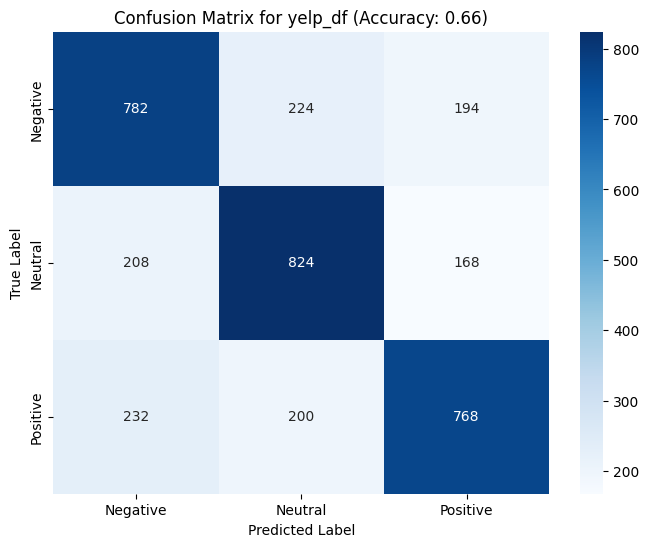

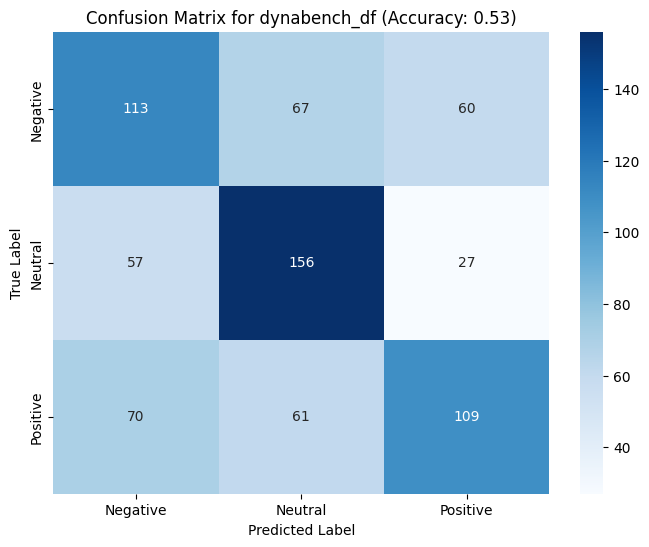

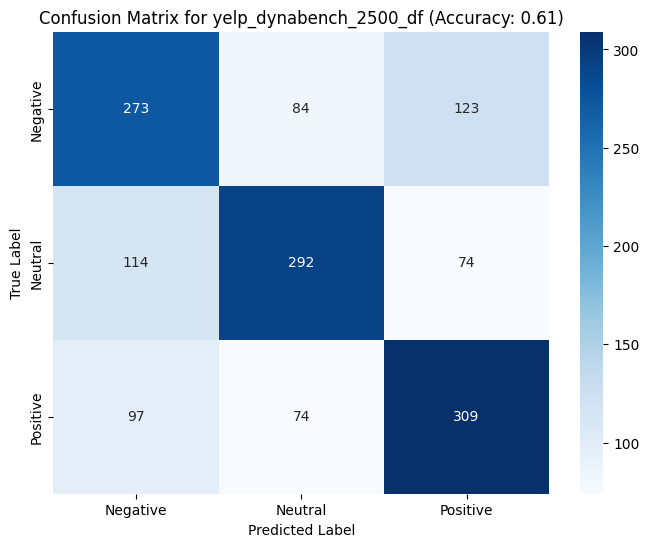

In [9]:
# Function to calculate accuracy and plot confusion matrix
dataset_names = ['yelp_df', 'dynabench_df', 'yelp_dynabench_2500_df']
def evaluate_sentiment(df_y_test, df_y_pred, df_name):
    accuracy = accuracy_score(df_y_test, df_y_pred)
    conf_matrix = confusion_matrix(df_y_test, df_y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix for {df_name} (Accuracy: {accuracy:.2f})')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
# Evaluate each prediction
for df_name, (df_y_test, df_y_pred) in zip(dataset_names, prediction):
    evaluate_sentiment(df_y_test, df_y_pred, df_name)